In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
client_path = os.path.join("data", "client_data.csv")
df_client = pd.read_csv(client_path)
print(df_client.head(3))

client_path = os.path.join("data", "price_data.csv")
df_price = pd.read_csv(client_path)
print(df_price.head(3))

                                 id                     channel_sales  \
0  24011ae4ebbe3035111d65fa7c15bc57  foosdfpfkusacimwkcsosbicdxkicaua   
1  d29c2c54acc38ff3c0614d0a653813dd                           MISSING   
2  764c75f661154dac3a6c254cd082ea7d  foosdfpfkusacimwkcsosbicdxkicaua   

   cons_12m  cons_gas_12m  cons_last_month  date_activ    date_end  \
0         0         54946                0  2013-06-15  2016-06-15   
1      4660             0                0  2009-08-21  2016-08-30   
2       544             0                0  2010-04-16  2016-04-16   

  date_modif_prod date_renewal  forecast_cons_12m  ...  has_gas  imp_cons  \
0      2015-11-01   2015-06-23               0.00  ...        t       0.0   
1      2009-08-21   2015-08-31             189.95  ...        f       0.0   
2      2010-04-16   2015-04-17              47.96  ...        f       0.0   

   margin_gross_pow_ele  margin_net_pow_ele  nb_prod_act  net_margin  \
0                 25.44               25.44  

In [6]:
client_subset =df_client[['id', 'churn', 'date_modif_prod']]


# Step 2: Merge the subset into the price dataframe using 'id' as the key
merged_price_df = pd.merge(df_price, client_subset, on='id', how='left')

# View the updated pricing dataframe
print(merged_price_df.head())

                                 id  price_date  price_off_peak_var  \
0  038af19179925da21a25619c5a24b745  2015-01-01            0.151367   
1  038af19179925da21a25619c5a24b745  2015-02-01            0.151367   
2  038af19179925da21a25619c5a24b745  2015-03-01            0.151367   
3  038af19179925da21a25619c5a24b745  2015-04-01            0.149626   
4  038af19179925da21a25619c5a24b745  2015-05-01            0.149626   

   price_peak_var  price_mid_peak_var  price_off_peak_fix  price_peak_fix  \
0             0.0                 0.0           44.266931             0.0   
1             0.0                 0.0           44.266931             0.0   
2             0.0                 0.0           44.266931             0.0   
3             0.0                 0.0           44.266931             0.0   
4             0.0                 0.0           44.266931             0.0   

   price_mid_peak_fix  churn date_modif_prod  
0                 0.0    0.0      2015-04-29  
1               

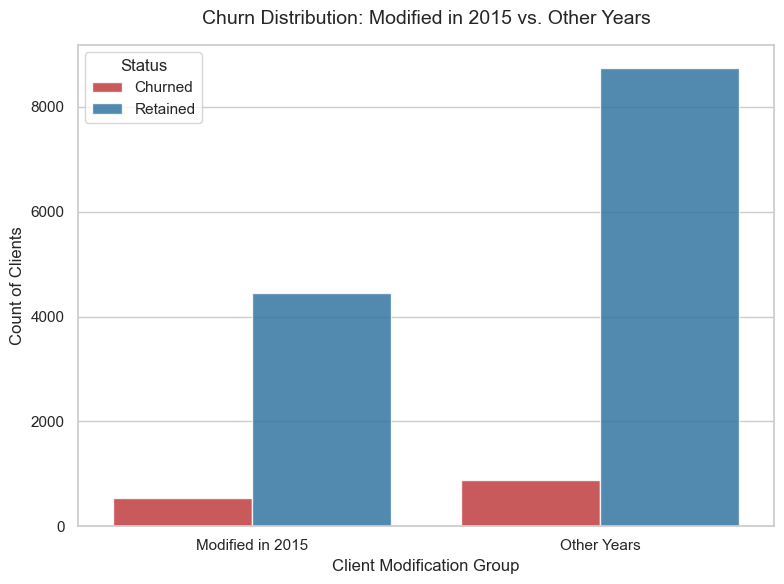

--- Exact Breakdown ---
Status              Churned  Retained
Modification Group                   
Modified in 2015        534      4440
Other Years             885      8747

--- Churn Rate Comparison ---
Modification Group
Modified in 2015    10.735826
Other Years          9.188123
Name: churn, dtype: float64


In [12]:
df_client['date_modif_prod'] = pd.to_datetime(df_client['date_modif_prod'])

# 2. Create a flag column: True if the year is 2015, False otherwise
df_client['modified_in_2015'] = df_client['date_modif_prod'].dt.year == 2015

# 3. Map the flag and churn status to clean text labels for the plot
df_client['Modification Group'] = df_client['modified_in_2015'].map({True: 'Modified in 2015', False: 'Other Years'})
df_client['Status'] = df_client['churn'].map({0: 'Retained', 1: 'Churned'})

# 4. Generate the count plot
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

sns.countplot(
    data=df_client,
    x='Modification Group',
    hue='Status',
    palette={'Retained': '#1f77b4', 'Churned': '#d62728'},
    edgecolor='white',
    alpha=0.85
)

# 5. Add titles and labels
plt.title('Churn Distribution: Modified in 2015 vs. Other Years', fontsize=14, pad=15)
plt.xlabel('Client Modification Group', fontsize=12)
plt.ylabel('Count of Clients', fontsize=12)
plt.legend(title='Status')

plt.tight_layout()
plt.show()

# Optional: Print out the exact numbers and churn rates for both groups
print("--- Exact Breakdown ---")
print(pd.crosstab(df_client['Modification Group'], df_client['Status']))

print("\n--- Churn Rate Comparison ---")
print(df_client.groupby('Modification Group')['churn'].mean() * 100)

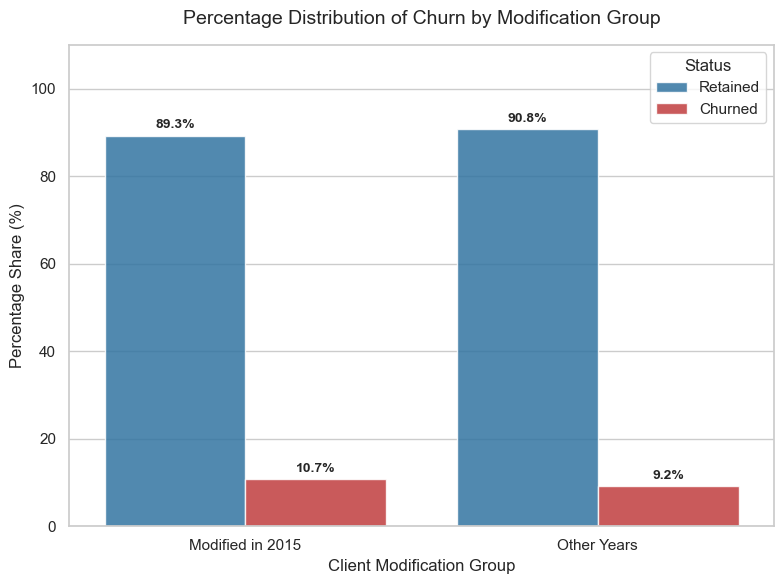

--- Percentage Distribution Matrix ---
churn                       0          1
Modification Group                      
Modified in 2015    89.264174  10.735826
Other Years         90.811877   9.188123


In [13]:


# 1. Ensure date_modif_prod is in datetime format
df_client['date_modif_prod'] = pd.to_datetime(df_client['date_modif_prod'])

# 2. Create the modification flag and human-readable groups
df_client['modified_in_2015'] = df_client['date_modif_prod'].dt.year == 2015
df_client['Modification Group'] = df_client['modified_in_2015'].map({True: 'Modified in 2015', False: 'Other Years'})

# 3. Compute the normalized percentages (relative to each group)
# This calculates the exact % of Churned vs Retained *within* each modification category
percentage_data = (
    df_client.groupby('Modification Group')['churn']
    .value_counts(normalize=True)
    .rename('Percentage')
    .reset_index()
)

# Convert the 0/1 churn markers into readable text labels for the plot
percentage_data['Status'] = percentage_data['churn'].map({0: 'Retained', 1: 'Churned'})
percentage_data['Percentage'] *= 100  # Convert fractions (0.90) to clean percentages (90.0)

# 4. Generate the percentage-based distribution plot
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=percentage_data,
    x='Modification Group',
    y='Percentage',
    hue='Status',
    palette={'Retained': '#1f77b4', 'Churned': '#d62728'},
    edgecolor='white',
    alpha=0.85
)

# 5. Annotate the exact percentages directly on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10, weight='bold')

# 6. Clean up labels and presentation
plt.title('Percentage Distribution of Churn by Modification Group', fontsize=14, pad=15)
plt.xlabel('Client Modification Group', fontsize=12)
plt.ylabel('Percentage Share (%)', fontsize=12)
plt.ylim(0, 110)  # Add breathing room for the top text labels
plt.legend(title='Status')

plt.tight_layout()
plt.show()

# Print the final matrix breakdown to the console
print("--- Percentage Distribution Matrix ---")
print(pd.crosstab(df_client['Modification Group'], df_client['churn'], normalize='index') * 100)

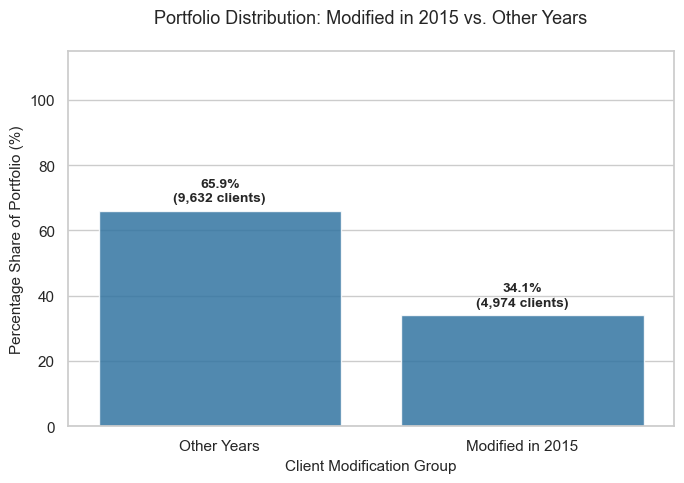

--- Portfolio Distribution Summary ---
Modification Group  Count  Percentage
       Other Years   9632   65.945502
  Modified in 2015   4974   34.054498


In [14]:
df_client['date_modif_prod'] = pd.to_datetime(df_client['date_modif_prod'])

# 2. Create the modification flag and human-readable groups
df_client['modified_in_2015'] = df_client['date_modif_prod'].dt.year == 2015
df_client['Modification Group'] = df_client['modified_in_2015'].map({True: 'Modified in 2015', False: 'Other Years'})

# 3. Calculate both the raw counts and the percentage distribution
group_counts = df_client['Modification Group'].value_counts()
group_percentages = df_client['Modification Group'].value_counts(normalize=True) * 100

# Combine them into a clean summary DataFrame for plotting
summary_df = pd.DataFrame({
    'Count': group_counts,
    'Percentage': group_percentages
}).reset_index().rename(columns={'index': 'Modification Group'})

# 4. Generate the percentage-based distribution plot
plt.figure(figsize=(7, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=summary_df,
    x='Modification Group',
    y='Percentage',
    color='#1f77b4',  # Uniform blue color since we aren't splitting by churn
    edgecolor='white',
    alpha=0.85
)

# 5. Annotate the bars with BOTH the percentage and the raw client count
for i, bar in enumerate(ax.patches):
    # Get the corresponding count and percentage values
    pct = summary_df.loc[i, 'Percentage']
    count = summary_df.loc[i, 'Count']
    
    # Create a clean label text showing both metrics
    label_text = f"{pct:.1f}%\n({count:,} clients)"
    
    # Place the text on top of each bar
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        label_text,
        ha='center',
        va='bottom',
        fontsize=10,
        weight='bold'
    )

# 6. Clean up labels and presentation
plt.title('Portfolio Distribution: Modified in 2015 vs. Other Years', fontsize=13, pad=20)
plt.xlabel('Client Modification Group', fontsize=11)
plt.ylabel('Percentage Share of Portfolio (%)', fontsize=11)
plt.ylim(0, 115)  # Add extra headroom for the text blocks

plt.tight_layout()
plt.show()

# Print the clean summary table directly to your console
print("--- Portfolio Distribution Summary ---")
print(summary_df.to_string(index=False))

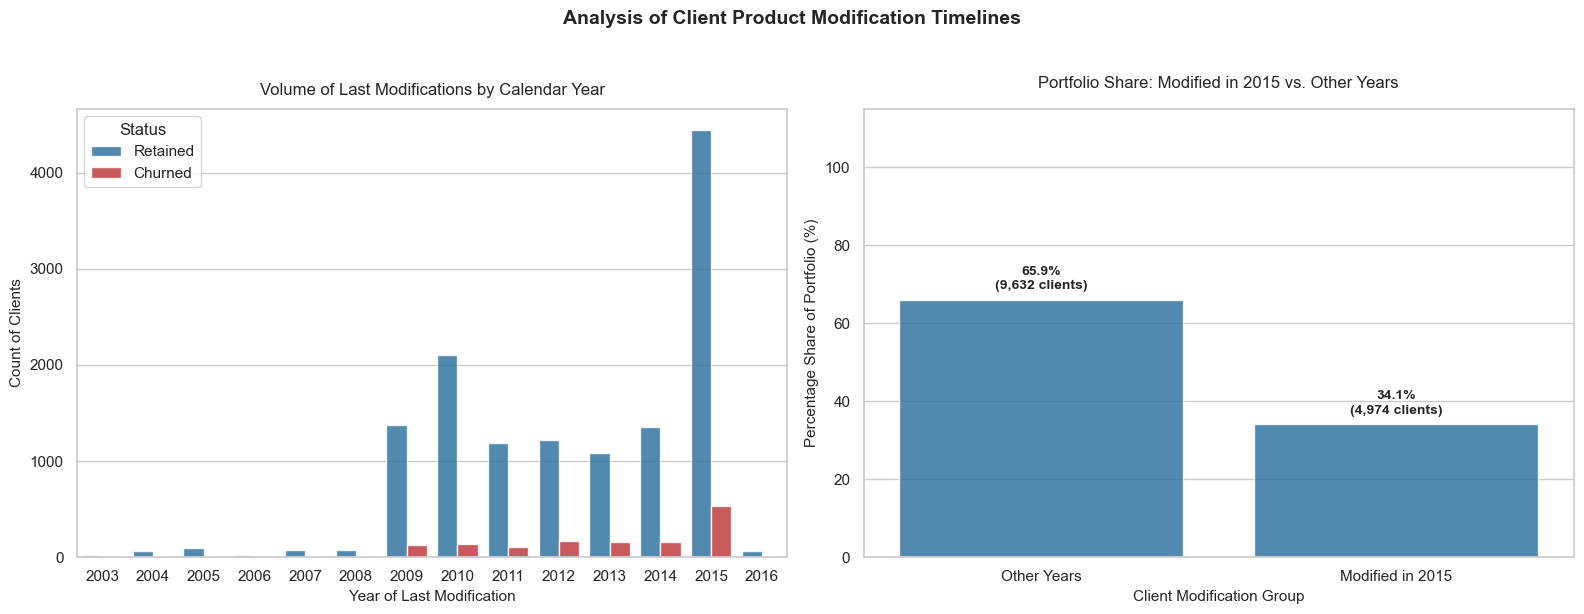

In [23]:
# 1. Ensure date_modif_prod is in datetime format
df_client['date_modif_prod'] = pd.to_datetime(df_client['date_modif_prod'])

# 2. Engineer the year and group features
df_client['year_modif'] = df_client['date_modif_prod'].dt.year

df_client['modified_in_2015'] = df_client['date_modif_prod'].dt.year == 2015
df_client['Modification Group'] = df_client['modified_in_2015'].map({True: 'Modified in 2015', False: 'Other Years'})

df_client['Status'] = df_client['churn'].map({0: 'Retained', 1: 'Churned'})

# 3. Calculate metrics for the right-side summary plot
group_counts = df_client['Modification Group'].value_counts()
group_percentages = df_client['Modification Group'].value_counts(normalize=True) * 100

summary_df = pd.DataFrame({
    'Count': group_counts,
    'Percentage': group_percentages
}).reset_index().rename(columns={'index': 'Modification Group'})

# 4. Set up a 1-row, 2-column subplot figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# --- LEFT PLOT: Whole-Year Count Distribution ---
sns.countplot(
    data=df_client,
    x='year_modif',
    hue='Status',
    palette={'Retained': '#1f77b4', 'Churned': '#d62728'},
    edgecolor='white',
    alpha=0.85,
    ax=axes[0]
)
axes[0].set_title('Volume of Last Modifications by Calendar Year', fontsize=12, pad=10)
axes[0].set_xlabel('Year of Last Modification', fontsize=11)
axes[0].set_ylabel('Count of Clients', fontsize=11)
axes[0].legend(title='Status')

# --- RIGHT PLOT: 2015 Portfolio Share Percentage ---
ax2 = sns.barplot(
    data=summary_df,
    x='Modification Group',
    y='Percentage',
    color='#1f77b4',
    edgecolor='white',
    alpha=0.85,
    ax=axes[1]
)
axes[1].set_title('Portfolio Share: Modified in 2015 vs. Other Years', fontsize=12, pad=15)
axes[1].set_xlabel('Client Modification Group', fontsize=11)
axes[1].set_ylabel('Percentage Share of Portfolio (%)', fontsize=11)
axes[1].set_ylim(0, 115)

# Add both percentage and client counts on top of the right bars
for i, bar in enumerate(ax2.patches):
    pct = summary_df.loc[i, 'Percentage']
    count = summary_df.loc[i, 'Count']
    label_text = f"{pct:.1f}%\n({count:,} clients)"
    
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        label_text,
        ha='center',
        va='bottom',
        fontsize=10,
        weight='bold'
    )

# 5. Global polishing and display
plt.suptitle('Analysis of Client Product Modification Timelines', fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Modification_Timelines_chart.png', bbox_inches='tight')
plt.show()


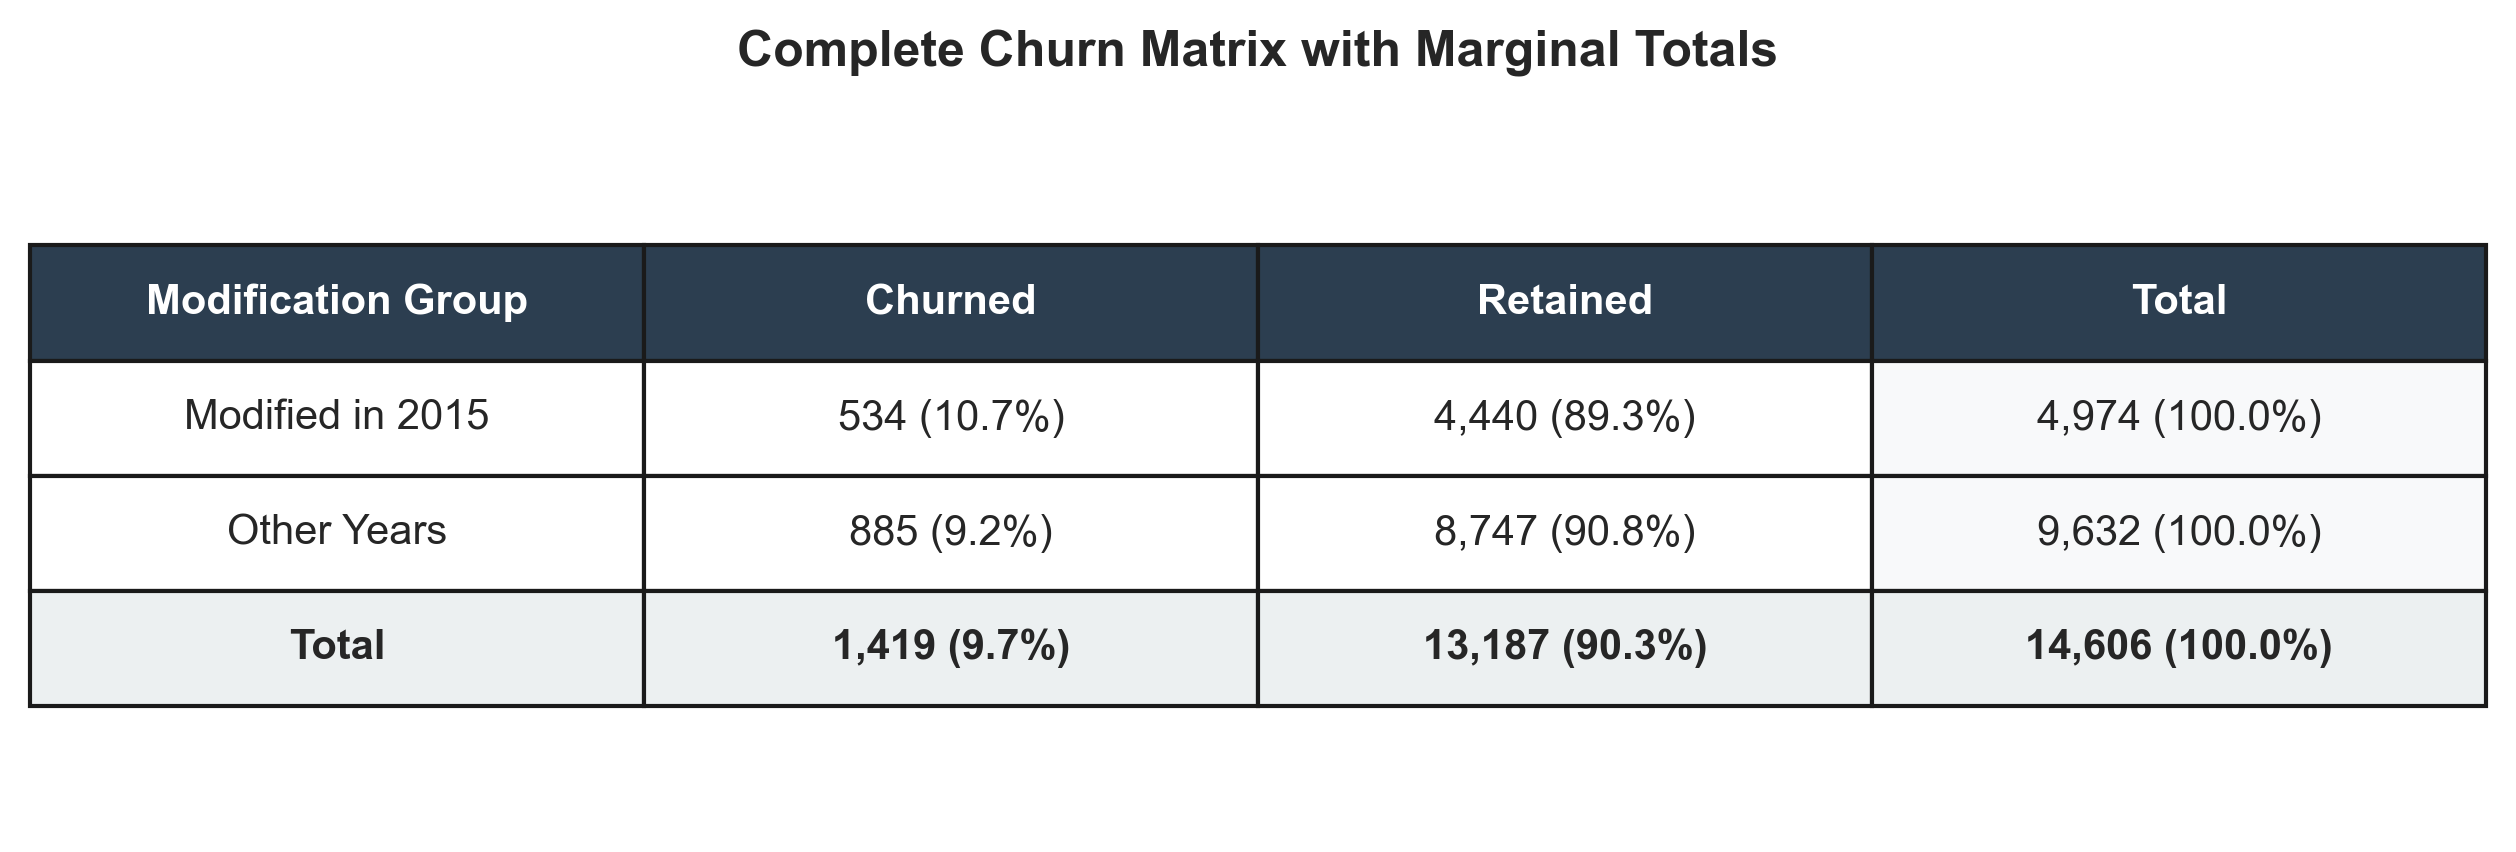

In [22]:


# 1. Structure the raw data into a DataFrame to easily calculate margins and totals
matrix_data = {
    'Churned': [534, 885],
    'Retained': [4440, 8747]
}
df_matrix = pd.DataFrame(matrix_data, index=['Modified in 2015', 'Other Years'])

# 2. Compute marginal row and column totals dynamically
df_matrix['Total'] = df_matrix['Churned'] + df_matrix['Retained']
total_row = pd.Series({
    'Churned': df_matrix['Churned'].sum(),
    'Retained': df_matrix['Retained'].sum(),
    'Total': df_matrix['Total'].sum()
}, name='Total')
df_matrix = pd.concat([df_matrix, total_row.to_frame().T])

# 3. Format the cells to display "Count (Percentage)" relative to their group total
formatted_cells = []
for idx, row in df_matrix.iterrows():
    row_total = row['Total']
    
    # Calculate group-specific percentages
    churn_pct = (row['Churned'] / row_total) * 100
    ret_pct = (row['Retained'] / row_total) * 100
    
    # Append the formatted string rows
    if idx == 'Total':
        # Overall portfolio baseline percentages
        formatted_cells.append([
            idx, 
            f"{row['Churned']:,} ({churn_pct:.1f}%)", 
            f"{row['Retained']:,} ({ret_pct:.1f}%)", 
            f"{row['Total']:,} (100.0%)"
        ])
    else:
        # Group-specific split percentages
        formatted_cells.append([
            idx, 
            f"{row['Churned']:,} ({churn_pct:.1f}%)", 
            f"{row['Retained']:,} ({ret_pct:.1f}%)", 
            f"{row['Total']:,} (100.0%)"
        ])

columns = ["Modification Group", "Churned", "Retained", "Total"]

# 4. Initialize the Matplotlib plot window
fig, ax = plt.subplots(figsize=(8.5, 3), dpi=300)
ax.axis('off')

# 5. Render the table grid inside the plot window
table = ax.table(
    cellText=formatted_cells,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

# 6. Apply professional clean styling and cell scaling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.3)

# Highlight headers and bottom total rows structurally
for (row, col), cell in table.get_celld().items():
    if row == 0:
        # Header Row Styling
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2c3e50')
    elif row == len(formatted_cells):
        # Marginal Total Row Styling
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#ecf0f1')
    elif col == 3:
        # Marginal Total Column Background Accent
        cell.set_facecolor('#f8f9fa')

plt.title('Complete Churn Matrix with Marginal Totals', fontsize=12, pad=15, weight='bold')
plt.tight_layout()
plt.savefig('Modification_Timelines.png', bbox_inches='tight')

plt.show()



In [24]:
df_client['date_modif_prod'] = pd.to_datetime(df_client['date_modif_prod'])

# 2. Filter rows where the year component equals 2015
df_2015_clients = df_client[df_client['date_modif_prod'].dt.year == 2015]

# View the filtered subset
print(f"Total clients modified in 2015: {len(df_2015_clients)}")
print(df_2015_clients.head())

Total clients modified in 2015: 4974
                                  id                     channel_sales  \
0   24011ae4ebbe3035111d65fa7c15bc57  foosdfpfkusacimwkcsosbicdxkicaua   
5   1aa498825382410b098937d65c4ec26d  usilxuppasemubllopkaafesmlibmsdf   
9   10c1b2f97a2d2a6f10299dc213d1a370  lmkebamcaaclubfxadlmueccxoimlema   
13  21860c2ff2d5df75503b230ce629c253  foosdfpfkusacimwkcsosbicdxkicaua   
22  78014630fbac3e6aa980361d25cea748  usilxuppasemubllopkaafesmlibmsdf   

    cons_12m  cons_gas_12m  cons_last_month  date_activ   date_end  \
0          0         54946                0  2013-06-15 2016-06-15   
5       8302             0             1998  2011-12-09 2016-12-09   
9      26064             0             2188  2010-05-04 2016-05-04   
13      7726             0                0  2013-01-22 2017-01-22   
22     20560             0             3804  2012-12-31 2016-12-31   

   date_modif_prod date_renewal  forecast_cons_12m  ...  nb_prod_act  \
0       2015-11-01   2015

In [25]:
merged_2015_price_df = pd.merge(df_2015_clients, df_price, on='id', how='inner')

# View the combined dataset
print(f"Total historical price records for 2015-modified clients: {len(merged_2015_price_df):,}")
print(merged_2015_price_df.head())

Total historical price records for 2015-modified clients: 59,623
                                 id                     channel_sales  \
0  24011ae4ebbe3035111d65fa7c15bc57  foosdfpfkusacimwkcsosbicdxkicaua   
1  24011ae4ebbe3035111d65fa7c15bc57  foosdfpfkusacimwkcsosbicdxkicaua   
2  24011ae4ebbe3035111d65fa7c15bc57  foosdfpfkusacimwkcsosbicdxkicaua   
3  24011ae4ebbe3035111d65fa7c15bc57  foosdfpfkusacimwkcsosbicdxkicaua   
4  24011ae4ebbe3035111d65fa7c15bc57  foosdfpfkusacimwkcsosbicdxkicaua   

   cons_12m  cons_gas_12m  cons_last_month  date_activ   date_end  \
0         0         54946                0  2013-06-15 2016-06-15   
1         0         54946                0  2013-06-15 2016-06-15   
2         0         54946                0  2013-06-15 2016-06-15   
3         0         54946                0  2013-06-15 2016-06-15   
4         0         54946                0  2013-06-15 2016-06-15   

  date_modif_prod date_renewal  forecast_cons_12m  ...   Status  \
0      2015-11

C:\Users\yuqin\AppData\Local\Temp\ipykernel_59340\1895572263.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2015_clients['date_modif_prod'] = pd.to_datetime(df_2015_clients['date_modif_prod'])
C:\Users\yuqin\AppData\Local\Temp\ipykernel_59340\1895572263.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2015_clients['month_modif'] = df_2015_clients['date_modif_prod'].dt.month
C:\Users\yuqin\AppData\Local\Temp\ipykernel_59340\1895572263.py:8: SettingWithCopyWarning: 
A value is trying to be set o

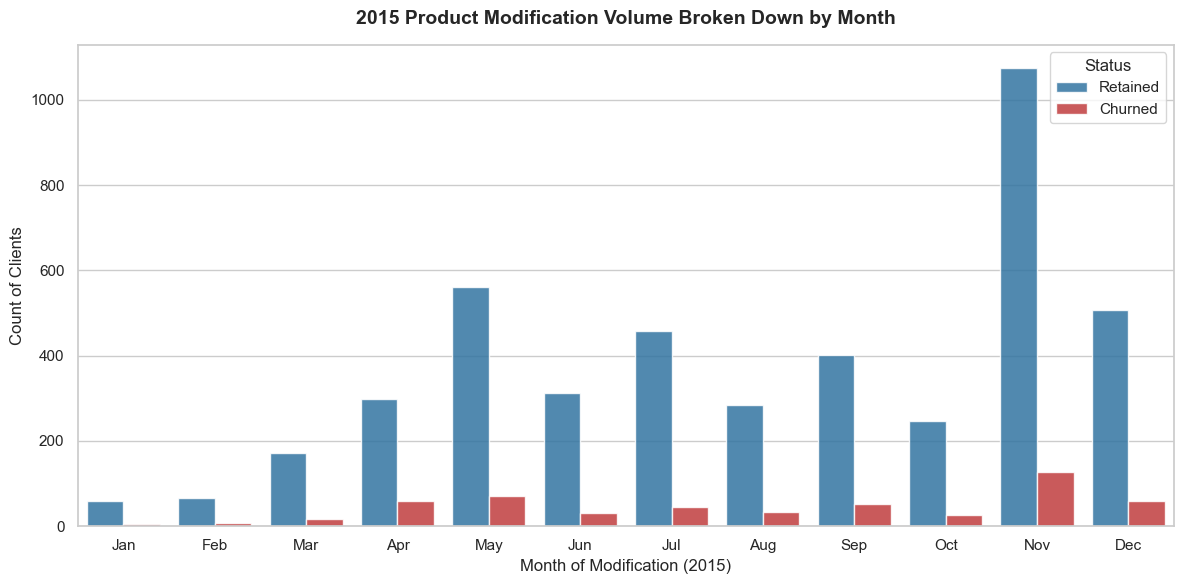

--- Monthly Churn Volume Matrix (2015) ---
Status  Churned  Retained
Jan           5        58
Feb           8        66
Mar          17       171
Apr          59       299
May          71       560
Jun          31       313
Jul          44       458
Aug          33       285
Sep          52       402
Oct          27       246
Nov         128      1075
Dec          59       507


In [26]:


# 1. Ensure the date column is in datetime format
df_2015_clients['date_modif_prod'] = pd.to_datetime(df_2015_clients['date_modif_prod'])

# 2. Extract the month as an integer (1 through 12)
df_2015_clients['month_modif'] = df_2015_clients['date_modif_prod'].dt.month

# 3. Map the churn column to clean text labels for the legend
df_2015_clients['Status'] = df_2015_clients['churn'].map({0: 'Retained', 1: 'Churned'})

# 4. Generate the distribution plot by month
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Create a clean month-by-month count plot split by churn status
sns.countplot(
    data=df_2015_clients,
    x='month_modif',
    hue='Status',
    palette={'Retained': '#1f77b4', 'Churned': '#d62728'},
    edgecolor='white',
    alpha=0.85
)

# 5. Make the X-axis show text month abbreviations instead of numbers (1-12)
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(ticks=range(0, 12), labels=month_labels)

# 6. Clean up labels and presentation
plt.title('2015 Product Modification Volume Broken Down by Month', fontsize=14, pad=15, weight='bold')
plt.xlabel('Month of Modification (2015)', fontsize=12)
plt.ylabel('Count of Clients', fontsize=12)
plt.legend(title='Status')

plt.tight_layout()
plt.show()

# Optional: Print out the exact monthly counts and churn rates to your console
print("--- Monthly Churn Volume Matrix (2015) ---")
monthly_matrix = pd.crosstab(df_2015_clients['month_modif'], df_2015_clients['Status'])
monthly_matrix.index = month_labels
print(monthly_matrix)

C:\Users\yuqin\AppData\Local\Temp\ipykernel_59340\2576251962.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2015_clients['date_modif_prod'] = pd.to_datetime(df_2015_clients['date_modif_prod'])
C:\Users\yuqin\AppData\Local\Temp\ipykernel_59340\2576251962.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2015_clients['month_modif'] = df_2015_clients['date_modif_prod'].dt.month
C:\Users\yuqin\AppData\Local\Temp\ipykernel_59340\2576251962.py:6: SettingWithCopyWarning: 
A value is trying to be set o

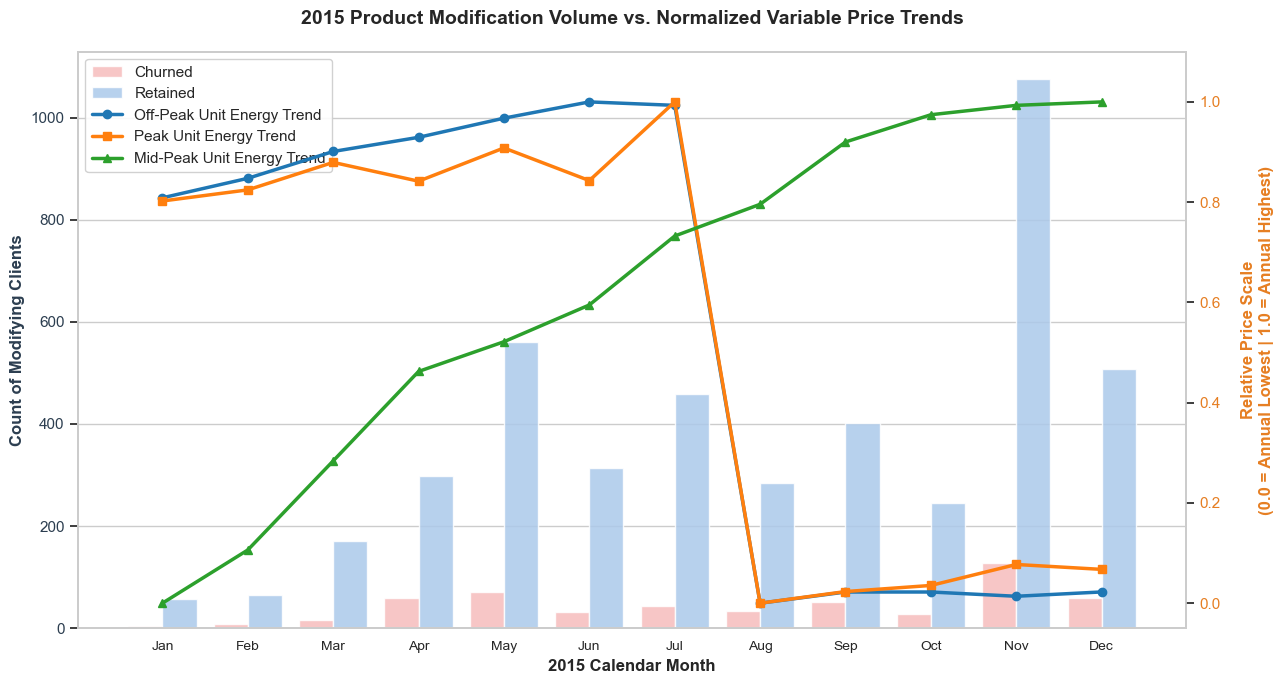

In [27]:


# =====================================================================
# STEP 1: Process the 2015 Client Modification Volume (Bar Data)
# =====================================================================
df_2015_clients['date_modif_prod'] = pd.to_datetime(df_2015_clients['date_modif_prod'])
df_2015_clients['month_modif'] = df_2015_clients['date_modif_prod'].dt.month
df_2015_clients['Status'] = df_2015_clients['churn'].map({0: 'Retained', 1: 'Churned'})

# Create a uniform monthly index (1 to 12) for counting modifications
monthly_counts = (
    df_2015_clients.groupby(['month_modif', 'Status'])
    .size()
    .unstack(fill_value=0)
    .reindex(range(1, 13), fill_value=0)
)

# =====================================================================
# STEP 2: Process and Normalize the Price Trend Data (Line Data)
# =====================================================================
var_cols = ['price_off_peak_var', 'price_peak_var', 'price_mid_peak_var']
df_var_only = df_price[['id', 'price_date'] + var_cols].copy()

# Exclude 0 values to protect baseline averages
for col in var_cols:
    df_var_only[col] = df_var_only[col].replace(0, float('nan'))

# Group by billing date and sort
monthly_var_averages = df_var_only.groupby('price_date')[var_cols].mean().reset_index()
monthly_var_averages = monthly_var_averages.sort_values('price_date')

# Map the price rows to matching months (1 to 12) to align with our bars
monthly_var_averages['price_date'] = pd.to_datetime(monthly_var_averages['price_date'])
monthly_var_averages['Month_Num'] = monthly_var_averages['price_date'].dt.month

# Apply Min-Max Normalization
monthly_var_normalized = monthly_var_averages.copy()
for col in var_cols:
    col_min = monthly_var_averages[col].min()
    col_max = monthly_var_averages[col].max()
    if col_max != col_min:
        monthly_var_normalized[col] = (monthly_var_averages[col] - col_min) / (col_max - col_min)
    else:
        monthly_var_normalized[col] = 0.0

# Ensure the price trends are grouped and indexed exactly 1 to 12
monthly_var_normalized = monthly_var_normalized.set_index('Month_Num').reindex(range(1, 13))

# =====================================================================
# STEP 3: Build the Dual-Axis Combined Plot
# =====================================================================
fig, ax1 = plt.subplots(figsize=(13, 7))
sns.set_theme(style="whitegrid")

# --- Primary Axis (Left Y-Axis): Modification Volume Bars ---
# Reset index for compatibility with seaborn's melting structure
bar_data = monthly_counts.reset_index().melt(id_vars='month_modif', value_name='Count')

sns.barplot(
    data=bar_data,
    x='month_modif',
    y='Count',
    hue='Status',
    palette={'Retained': '#a1c9f4', 'Churned': '#ffb3b3'}, # Muted bar colors to let lines pop
    edgecolor='white',
    alpha=0.85,
    ax=ax1
)

ax1.set_ylabel('Count of Modifying Clients', fontsize=12, weight='bold', color='#2c3e50')
ax1.set_xlabel('2015 Calendar Month', fontsize=12, weight='bold')
ax1.tick_params(axis='y', labelcolor='#2c3e50')
ax1.get_legend().remove() # Move the legend later to a unified window

# --- Secondary Axis (Right Y-Axis): Price Trend Lines ---
ax2 = ax1.twinx()

# Subtract 1 from the x positions (0 to 11) to perfectly align line points with the bar groups
x_positions = [x for x in range(12)]

ax2.plot(x_positions, monthly_var_normalized['price_off_peak_var'], marker='o', linewidth=2.5, color='#1f77b4', label='Off-Peak Unit Energy Trend')
ax2.plot(x_positions, monthly_var_normalized['price_peak_var'], marker='s', linewidth=2.5, color='#ff7f0e', label='Peak Unit Energy Trend')
ax2.plot(x_positions, monthly_var_normalized['price_mid_peak_var'], marker='^', linewidth=2.5, color='#2ca02c', label='Mid-Peak Unit Energy Trend')

ax2.set_ylabel('Relative Price Scale\n(0.0 = Annual Lowest | 1.0 = Annual Highest)', fontsize=12, weight='bold', color='#e67e22', labelpad=15)
ax2.tick_params(axis='y', labelcolor='#e67e22')
ax2.set_ylim(-0.05, 1.1) # Extra space at the top to prevent overlapping
ax2.grid(False) # Turn off right grid to keep the background clean

# --- Formatting Labels & Legend ---
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax1.set_xticks(range(12))
ax1.set_xticklabels(month_labels, fontsize=10)

# Merge legends from both axes cleanly
lines, labels = ax2.get_legend_handles_labels()
bars, bar_labels = ax1.get_legend_handles_labels()
ax1.legend(bars + lines, bar_labels + labels, loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

plt.title('2015 Product Modification Volume vs. Normalized Variable Price Trends', fontsize=14, pad=20, weight='bold')
plt.tight_layout()
plt.savefig('combined_modification_and_price_trends.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\yuqin\AppData\Local\Temp\ipykernel_59340\2699814060.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2015_clients['date_modif_prod'] = pd.to_datetime(df_2015_clients['date_modif_prod'])
C:\Users\yuqin\AppData\Local\Temp\ipykernel_59340\2699814060.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2015_clients['month_modif'] = df_2015_clients['date_modif_prod'].dt.month
C:\Users\yuqin\AppData\Local\Temp\ipykernel_59340\2699814060.py:3: SettingWithCopyWarning: 
A value is trying to be set o

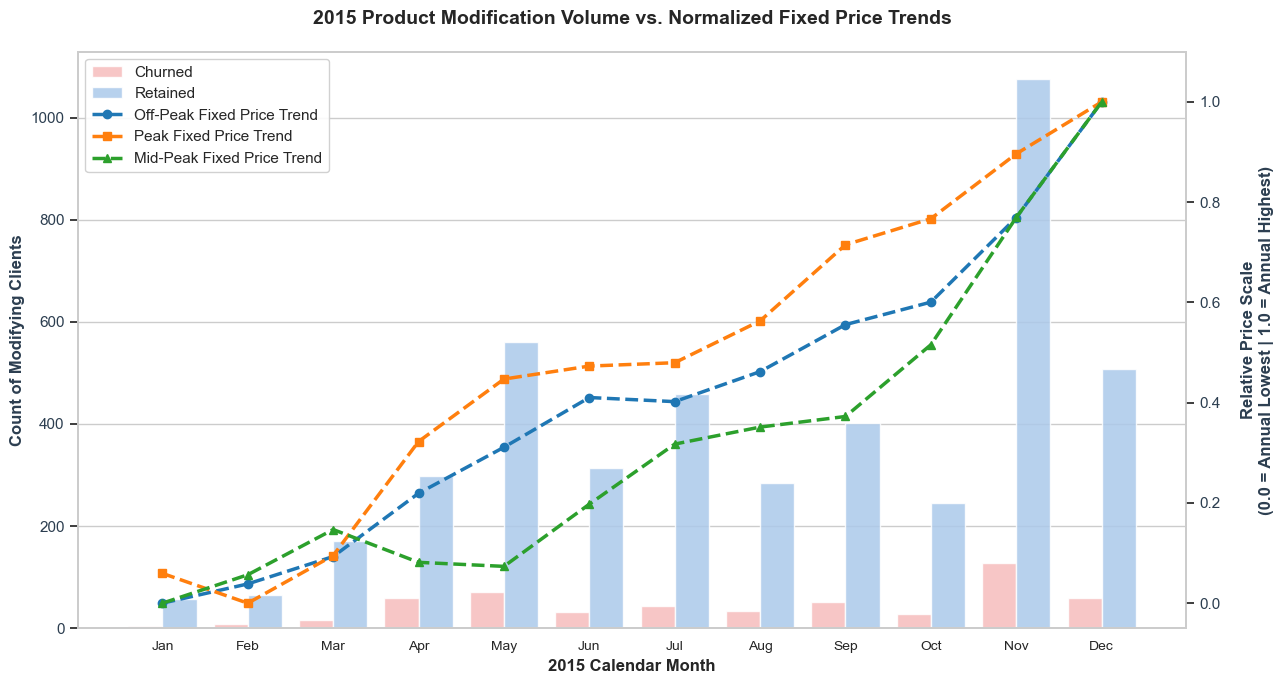

In [28]:
df_2015_clients['date_modif_prod'] = pd.to_datetime(df_2015_clients['date_modif_prod'])
df_2015_clients['month_modif'] = df_2015_clients['date_modif_prod'].dt.month
df_2015_clients['Status'] = df_2015_clients['churn'].map({0: 'Retained', 1: 'Churned'})

# Create a uniform monthly index (1 to 12) for counting modifications
monthly_counts = (
    df_2015_clients.groupby(['month_modif', 'Status'])
    .size()
    .unstack(fill_value=0)
    .reindex(range(1, 13), fill_value=0)
)

# =====================================================================
# STEP 2: Process and Normalize the Fixed Price Trend Data (Line Data)
# =====================================================================
# Isolate the fixed power price columns this time
fix_cols = ['price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix']
df_fix_only = df_price[['id', 'price_date'] + fix_cols].copy()

# Exclude 0 values to protect baseline averages
for col in fix_cols:
    df_fix_only[col] = df_fix_only[col].replace(0, float('nan'))

# Group by billing date and sort
monthly_fix_averages = df_fix_only.groupby('price_date')[fix_cols].mean().reset_index()
monthly_fix_averages = monthly_fix_averages.sort_values('price_date')

# Map the price rows to matching months (1 to 12) to align with our bars
monthly_fix_averages['price_date'] = pd.to_datetime(monthly_fix_averages['price_date'])
monthly_fix_averages['Month_Num'] = monthly_fix_averages['price_date'].dt.month

# Apply Min-Max Normalization to force the unit scales into a 0.0 to 1.0 box
monthly_fix_normalized = monthly_fix_averages.copy()
for col in fix_cols:
    col_min = monthly_fix_averages[col].min()
    col_max = monthly_fix_averages[col].max()
    if col_max != col_min:
        monthly_fix_normalized[col] = (monthly_fix_averages[col] - col_min) / (col_max - col_min)
    else:
        monthly_fix_normalized[col] = 0.0

# Ensure the price trends are grouped and indexed exactly 1 to 12
monthly_fix_normalized = monthly_fix_normalized.set_index('Month_Num').reindex(range(1, 13))

# =====================================================================
# STEP 3: Build the Dual-Axis Combined Plot
# =====================================================================
fig, ax1 = plt.subplots(figsize=(13, 7))
sns.set_theme(style="whitegrid")

# --- Primary Axis (Left Y-Axis): Modification Volume Bars ---
bar_data = monthly_counts.reset_index().melt(id_vars='month_modif', value_name='Count')

sns.barplot(
    data=bar_data,
    x='month_modif',
    y='Count',
    hue='Status',
    palette={'Retained': '#a1c9f4', 'Churned': '#ffb3b3'}, # Muted bars to let lines stand out
    edgecolor='white',
    alpha=0.85,
    ax=ax1
)

ax1.set_ylabel('Count of Modifying Clients', fontsize=12, weight='bold', color='#2c3e50')
ax1.set_xlabel('2015 Calendar Month', fontsize=12, weight='bold')
ax1.tick_params(axis='y', labelcolor='#2c3e50')
ax1.get_legend().remove() 

# --- Secondary Axis (Right Y-Axis): Fixed Price Trend Lines ---
ax2 = ax1.twinx()

# Shift x positions (0 to 11) to center line points perfectly above the bar categories
x_positions = [x for x in range(12)]

ax2.plot(x_positions, monthly_fix_normalized['price_off_peak_fix'], marker='o', linewidth=2.5, color='#1f77b4', linestyle='--', label='Off-Peak Fixed Price Trend')
ax2.plot(x_positions, monthly_fix_normalized['price_peak_fix'], marker='s', linewidth=2.5, color='#ff7f0e', linestyle='--', label='Peak Fixed Price Trend')
ax2.plot(x_positions, monthly_fix_normalized['price_mid_peak_fix'], marker='^', linewidth=2.5, color='#2ca02c', linestyle='--', label='Mid-Peak Fixed Price Trend')

ax2.set_ylabel('Relative Price Scale\n(0.0 = Annual Lowest | 1.0 = Annual Highest)', fontsize=12, weight='bold', color='#2c3e50', labelpad=15)
ax2.tick_params(axis='y', labelcolor='#2c3e50')
ax2.set_ylim(-0.05, 1.1) 
ax2.grid(False) # Clean background accentuation

# --- Formatting Labels & Legend ---
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax1.set_xticks(range(12))
ax1.set_xticklabels(month_labels, fontsize=10)

# Merge legends cleanly from both coordinate systems
lines, labels = ax2.get_legend_handles_labels()
bars, bar_labels = ax1.get_legend_handles_labels()
ax1.legend(bars + lines, bar_labels + labels, loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

plt.title('2015 Product Modification Volume vs. Normalized Fixed Price Trends', fontsize=14, pad=20, weight='bold')
plt.tight_layout()
plt.savefig('combined_modification_and_fixed_price_trends.png', dpi=300, bbox_inches='tight')
plt.show()

In [29]:


# 1. Ensure the price dates are proper datetime objects
df_price['price_date'] = pd.to_datetime(df_price['price_date'])

# 2. Sort the dataset by client ID first, and then chronologically by date
# This is critical so we don't accidentally compare Client A's price to Client B's price
df_price = df_price.sort_values(by=['id', 'price_date'])

# 3. Define the fixed price columns we want to monitor
fix_cols = ['price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix']

# 4. Create "shifted" columns that hold the previous month's prices for each client
previous_prices = df_price.groupby('id')[fix_cols].shift(1)

# 5. Compare the current month to the previous month
# We use .notna() to ignore the very first billing month (since there is no previous month to compare it to)
price_changed_mask = (df_price[fix_cols] != previous_prices) & previous_prices.notna()

# 6. Create a flag column: True if ANY of the three fixed prices changed
df_price['plan_changed'] = price_changed_mask.any(axis=1)

# 7. Extract the complete history of just the plan changes
df_plan_changes = df_price[df_price['plan_changed'] == True].copy()

# View the extracted history
print(f"Total fixed-price plan changes detected: {len(df_plan_changes):,}")
print(df_plan_changes[['id', 'price_date'] + fix_cols].head(10))

Total fixed-price plan changes detected: 23,684
                                      id price_date  price_off_peak_fix  \
72165   0002203ffbb812588b632b9e628cc38d 2015-03-01           40.728885   
157113  0004351ebdd665e6ee664792efc4fd13 2015-05-01           44.444710   
168215  0010bcc39e42b3c2131ed2ce55246e3c 2015-06-01           45.944710   
51909   0010ee3855fdea87602a5b7aba8e42de 2015-06-01           40.565973   
51910   0010ee3855fdea87602a5b7aba8e42de 2015-07-01           40.728885   
24564   00114d74e963e47177db89bc70108537 2015-05-01           44.266930   
99023   00126c87cf78d7604278f0a9adeb689e 2015-06-01           40.728885   
137838  00184e957277eeef733a7b563fdabd06 2015-05-01           44.266930   
154620  001987ed9dbdab4efa274a9c7233e1f4 2015-07-01           40.728885   
121318  0019baf3ed1242cd99b3cb592030446f 2015-02-01           59.206931   

        price_peak_fix  price_mid_peak_fix  
72165        24.437330           16.291555  
157113        0.000000            0.